In [1]:
import pandas as pd

daily_sales = pd.read_csv(
    "../data/processed/daily_sales.csv"
)

daily_sales.head()

,InvoiceDate,Revenue
0,2010-12-01,45867.26
1,2010-12-02,45656.47
2,2010-12-03,22553.38
3,2010-12-05,30970.28
4,2010-12-06,30258.77


In [3]:
from statsmodels.tsa.stattools import adfuller

In [4]:
sales_series = daily_sales["Revenue"]

In [5]:
result = adfuller(sales_series)

print("ADF Statistic:", result[0])
print("P-value:", result[1])

ADF Statistic: -1.243599121540923
P-value: 0.6545650745327604


<Axes: >

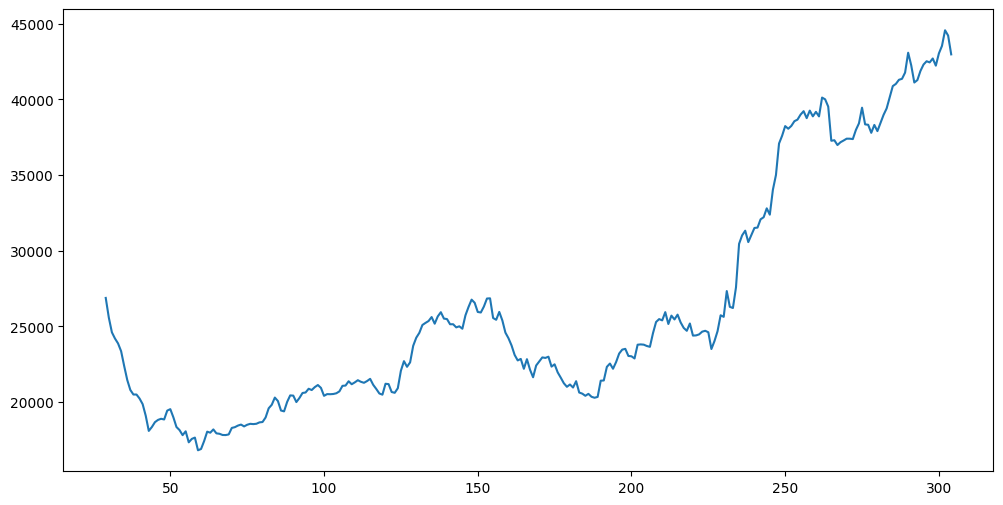

In [6]:
rolling_mean = sales_series.rolling(window=30).mean()

rolling_mean.plot(figsize=(12,6))

<Axes: >

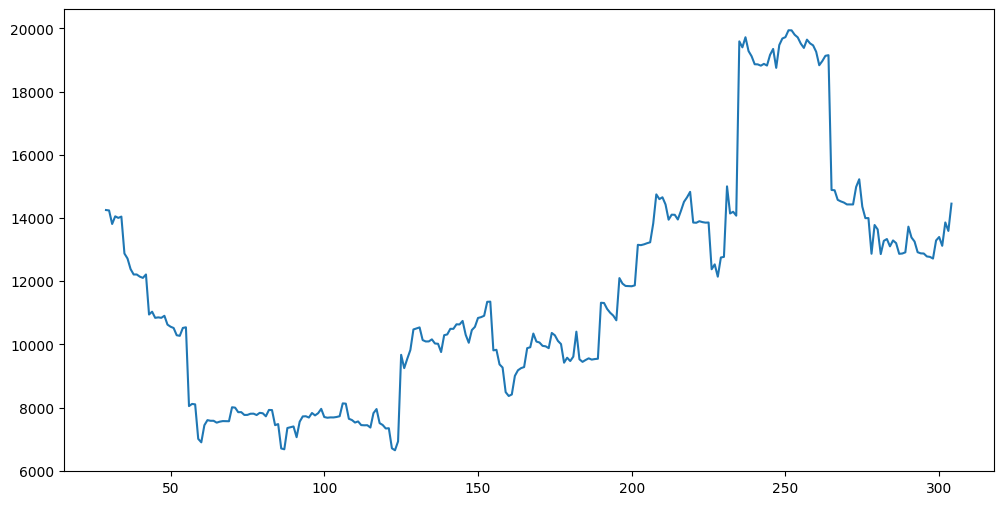

In [7]:
rolling_std = sales_series.rolling(window=30).std()

rolling_std.plot(figsize=(12,6))

In [8]:
print("P-value:", result[1])

P-value: 0.6545650745327604


In [9]:
import pandas as pd

daily_sales = pd.read_csv(
    "../data/processed/daily_sales.csv"
)

daily_sales.head()

,InvoiceDate,Revenue
0,2010-12-01,45867.26
1,2010-12-02,45656.47
2,2010-12-03,22553.38
3,2010-12-05,30970.28
4,2010-12-06,30258.77


In [10]:
prophet_df = daily_sales.copy()

prophet_df.columns = [
    "ds",
    "y"
]

prophet_df.head()

,ds,y
0,2010-12-01,45867.26
1,2010-12-02,45656.47
2,2010-12-03,22553.38
3,2010-12-05,30970.28
4,2010-12-06,30258.77


In [11]:
prophet_df["ds"] = pd.to_datetime(
    prophet_df["ds"]
)

prophet_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 305 entries, 0 to 304
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   ds      305 non-null    datetime64[us]
 1   y       305 non-null    float64       
dtypes: datetime64[us](1), float64(1)
memory usage: 4.9 KB


In [12]:
from prophet import Prophet

Importing plotly failed. Interactive plots will not work.


In [13]:
model = Prophet()

In [14]:
model.fit(prophet_df)

10:07:03 - cmdstanpy - INFO - Chain [1] start processing
10:07:04 - cmdstanpy - INFO - Chain [1] done processing


In [15]:
future = model.make_future_dataframe(
    periods=30
)

future.tail()

,ds
330,2012-01-04
331,2012-01-05
332,2012-01-06
333,2012-01-07
334,2012-01-08


In [16]:
forecast = model.predict(
    future
)

forecast.head()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,weekly,weekly_lower,weekly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2010-12-01,24217.112171,9484.324460,37745.034445,24217.112171,24217.112171,137.978096,137.978096,137.978096,137.978096,137.978096,137.978096,0.0,0.0,0.0,24355.090268
1,2010-12-02,24189.191923,17429.319881,45364.868067,24189.191923,24189.191923,7126.896934,7126.896934,7126.896934,7126.896934,7126.896934,7126.896934,0.0,0.0,0.0,31316.088857
2,2010-12-03,24161.271675,5688.634557,32914.121671,24161.271675,24161.271675,-4304.061428,-4304.061428,-4304.061428,-4304.061428,-4304.061428,-4304.061428,0.0,0.0,0.0,19857.210247
3,2010-12-05,24105.431179,-2797.430370,25245.359757,24105.431179,24105.431179,-13219.430349,-13219.430349,-13219.430349,-13219.430349,-13219.430349,-13219.430349,0.0,0.0,0.0,10886.000829
4,2010-12-06,24077.510931,7184.719678,36405.190589,24077.510931,24077.510931,-1905.836838,-1905.836838,-1905.836838,-1905.836838,-1905.836838,-1905.836838,0.0,0.0,0.0,22171.674093


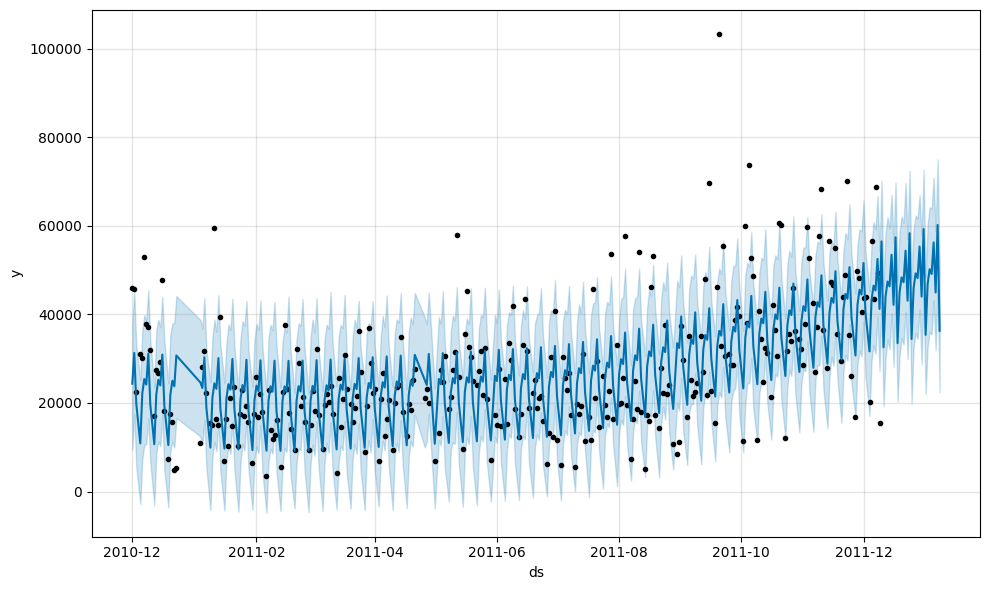

In [17]:
fig = model.plot(forecast)

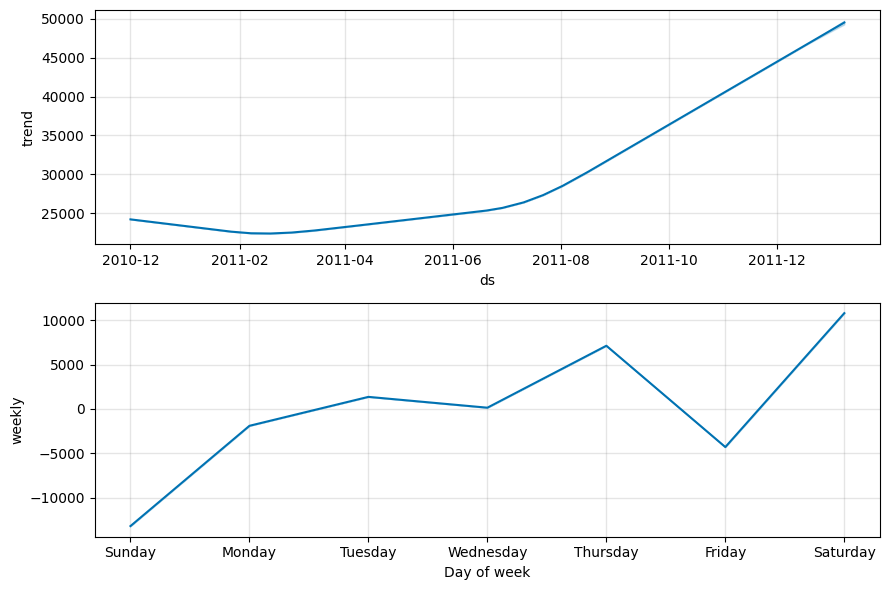

In [18]:
fig2 = model.plot_components(
    forecast
)

In [19]:
forecast.to_csv(
    "../data/processed/prophet_forecast.csv",
    index=False
)

In [1]:
import pandas as pd

df = pd.read_csv("../data/processed/cleaned_retail.csv")

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


In [2]:
customer_df = df.groupby("CustomerID").agg({
    "Revenue":"sum",
    "InvoiceNo":"count",
    "InvoiceDate":["min","max"]
})

customer_df.head()

Revenue InvoiceNo          InvoiceDate                     
                sum     count                  min                  max
CustomerID                                                             
12346.0        0.00         2  2011-01-18 10:01:00  2011-01-18 10:17:00
12347.0     4310.00       182  2010-12-07 14:57:00  2011-12-07 15:52:00
12348.0     1797.24        31  2010-12-16 19:09:00  2011-09-25 13:13:00
12349.0     1757.55        73  2011-11-21 09:51:00  2011-11-21 09:51:00
12350.0      334.40        17  2011-02-02 16:01:00  2011-02-02 16:01:00

In [3]:
customer_df.columns = [
    "Revenue",
    "Frequency",
    "FirstPurchase",
    "LastPurchase"
]

customer_df.head()

,Revenue,Frequency,FirstPurchase,LastPurchase
CustomerID,,,,
12346.0,0.00,2,2011-01-18 10:01:00,2011-01-18 10:17:00
12347.0,4310.00,182,2010-12-07 14:57:00,2011-12-07 15:52:00
12348.0,1797.24,31,2010-12-16 19:09:00,2011-09-25 13:13:00
12349.0,1757.55,73,2011-11-21 09:51:00,2011-11-21 09:51:00
12350.0,334.40,17,2011-02-02 16:01:00,2011-02-02 16:01:00


In [4]:
customer_df["LastPurchase"] = pd.to_datetime(
    customer_df["LastPurchase"]
)

reference_date = customer_df["LastPurchase"].max()

customer_df["DaysSinceLastPurchase"] = (
    reference_date - customer_df["LastPurchase"]
).dt.days

customer_df.head()

,Revenue,Frequency,FirstPurchase,LastPurchase,DaysSinceLastPurchase
CustomerID,,,,,
12346.0,0.00,2,2011-01-18 10:01:00,2011-01-18 10:17:00,325
12347.0,4310.00,182,2010-12-07 14:57:00,2011-12-07 15:52:00,1
12348.0,1797.24,31,2010-12-16 19:09:00,2011-09-25 13:13:00,74
12349.0,1757.55,73,2011-11-21 09:51:00,2011-11-21 09:51:00,18
12350.0,334.40,17,2011-02-02 16:01:00,2011-02-02 16:01:00,309


In [5]:
customer_df["Churn"] = (
    customer_df["DaysSinceLastPurchase"] > 90
).astype(int)

customer_df["Churn"].value_counts()

Churn
0    2922
1    1450
Name: count, dtype: int64

In [6]:
X = customer_df[
    [
        "Revenue",
        "Frequency",
        "DaysSinceLastPurchase"
    ]
]

y = customer_df["Churn"]

X.head()

,Revenue,Frequency,DaysSinceLastPurchase
CustomerID,,,
12346.0,0.00,2,325
12347.0,4310.00,182,1
12348.0,1797.24,31,74
12349.0,1757.55,73,18
12350.0,334.40,17,309


In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(3497, 3)
(875, 3)


In [8]:
from xgboost import XGBClassifier

model = XGBClassifier(
    random_state=42
)

model.fit(
    X_train,
    y_train
)

XGBoostError: 
XGBoost Library (libxgboost.dylib) could not be loaded.
Likely causes:
  * OpenMP runtime is not installed
    - vcomp140.dll or libgomp-1.dll for Windows
    - libomp.dylib for Mac OSX
    - libgomp.so for Linux and other UNIX-like OSes
    Mac OSX users: Run `brew install libomp` to install OpenMP runtime.

  * You are running 32-bit Python on a 64-bit OS

Error message(s): ["dlopen(/Users/kansagaradhrumi/Desktop/RetailPulse/venv/lib/python3.14/site-packages/xgboost/lib/libxgboost.dylib, 0x0006): Library not loaded: @rpath/libomp.dylib\n  Referenced from: <4E82201A-ED82-3451-AD25-7886C77941A1> /Users/kansagaradhrumi/Desktop/RetailPulse/venv/lib/python3.14/site-packages/xgboost/lib/libxgboost.dylib\n  Reason: tried: '/opt/homebrew/opt/libomp/lib/libomp.dylib' (no such file), '/System/Volumes/Preboot/Cryptexes/OS/opt/homebrew/opt/libomp/lib/libomp.dylib' (no such file), '/opt/homebrew/opt/libomp/lib/libomp.dylib' (no such file), '/System/Volumes/Preboot/Cryptexes/OS/opt/

In [1]:
from xgboost import XGBClassifier

model = XGBClassifier(
    random_state=42
)

model.fit(
    X_train,
    y_train
)

XGBoostError: 
XGBoost Library (libxgboost.dylib) could not be loaded.
Likely causes:
  * OpenMP runtime is not installed
    - vcomp140.dll or libgomp-1.dll for Windows
    - libomp.dylib for Mac OSX
    - libgomp.so for Linux and other UNIX-like OSes
    Mac OSX users: Run `brew install libomp` to install OpenMP runtime.

  * You are running 32-bit Python on a 64-bit OS

Error message(s): ["dlopen(/Users/kansagaradhrumi/Desktop/RetailPulse/venv/lib/python3.14/site-packages/xgboost/lib/libxgboost.dylib, 0x0006): Library not loaded: @rpath/libomp.dylib\n  Referenced from: <4E82201A-ED82-3451-AD25-7886C77941A1> /Users/kansagaradhrumi/Desktop/RetailPulse/venv/lib/python3.14/site-packages/xgboost/lib/libxgboost.dylib\n  Reason: tried: '/opt/homebrew/opt/libomp/lib/libomp.dylib' (no such file), '/System/Volumes/Preboot/Cryptexes/OS/opt/homebrew/opt/libomp/lib/libomp.dylib' (no such file), '/opt/homebrew/opt/libomp/lib/libomp.dylib' (no such file), '/System/Volumes/Preboot/Cryptexes/OS/opt/

In [1]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

NameError: name 'X_train' is not defined

In [2]:
X = customer_df[
    ["Recency", "Frequency", "Monetary"]
]

y = customer_df["Churn"]

NameError: name 'customer_df' is not defined